--- PXP Model: Strict Clifford 3-design Convergence (L=8) ---


Simulating Time Steps: 100%|███████████████████████████████████████████████████████████| 20/20 [12:53<00:00, 38.67s/it]


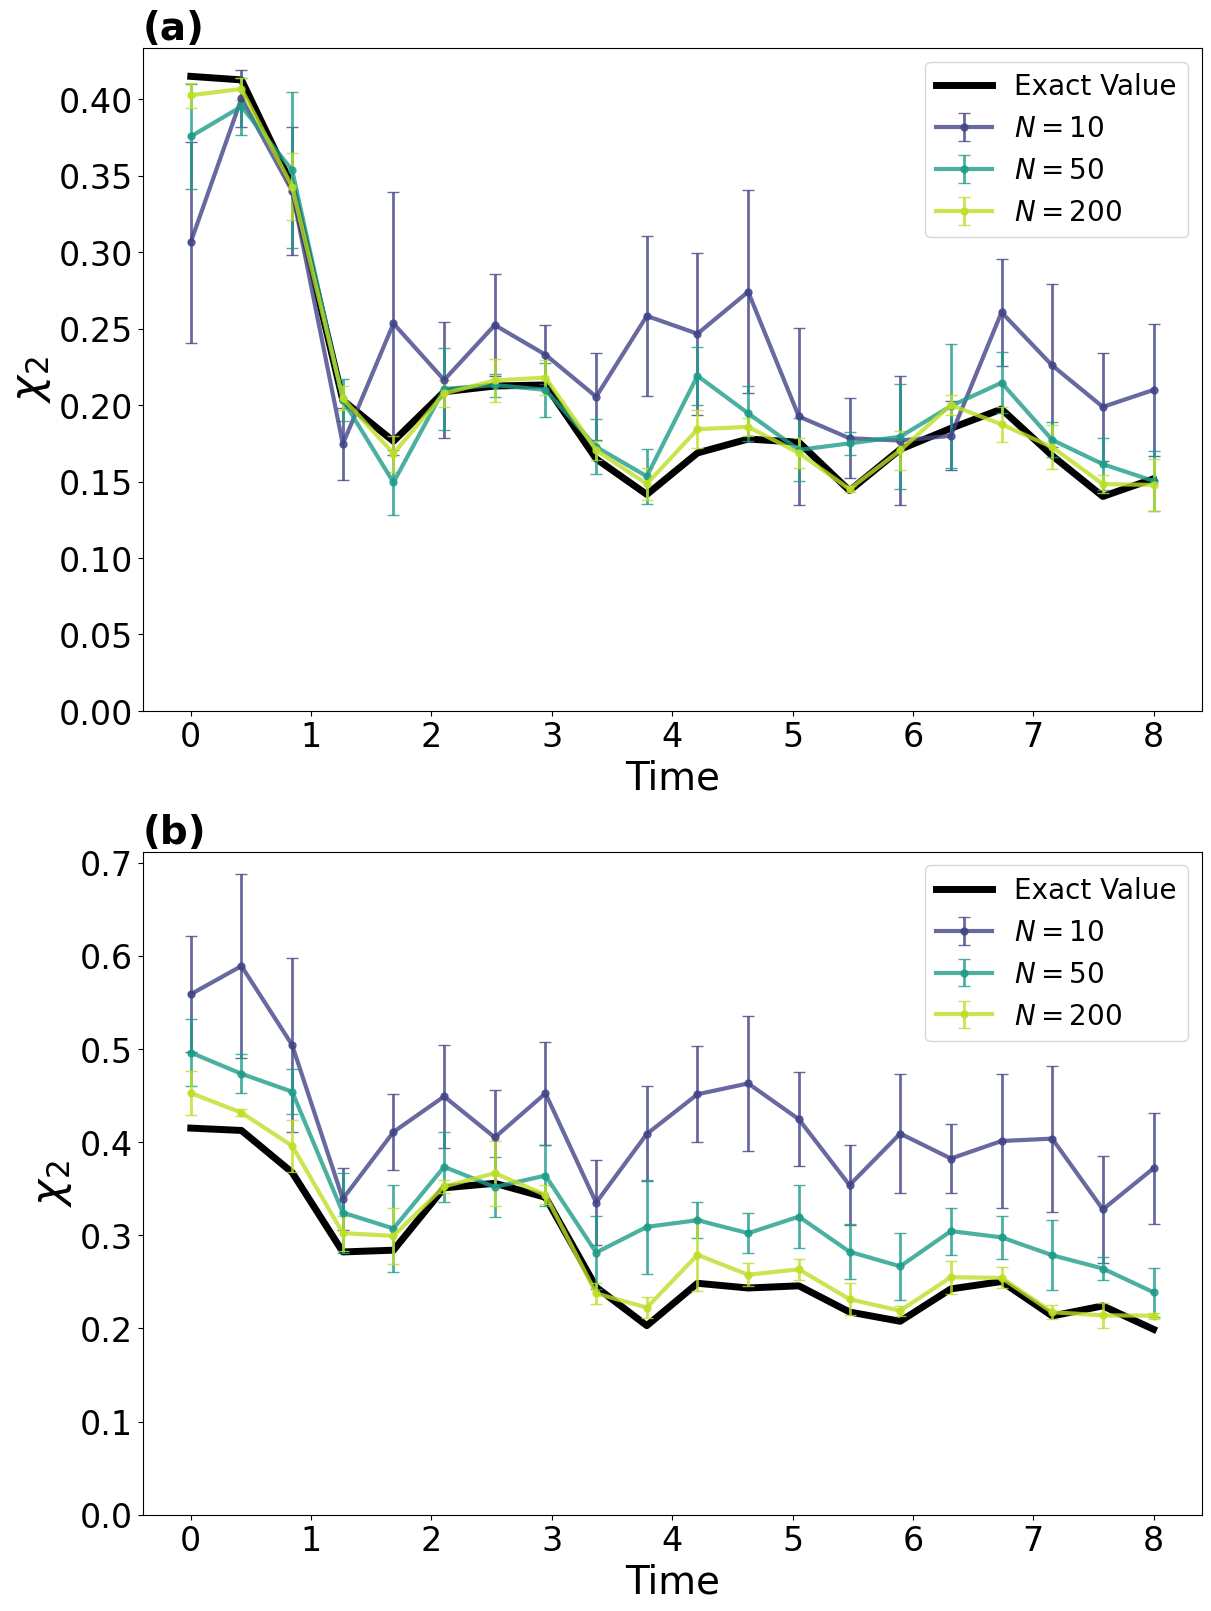

In [3]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply
from scipy.stats import unitary_group
import matplotlib.pyplot as plt
from tqdm import tqdm
import itertools
import os
import warnings

warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 1. 系统与计算工具 
def get_exact_reduced_rho(psi, L, target_sites):
    psi_tensor = psi.reshape([2] * L)
    axes_to_keep = list(target_sites)
    axes_to_trace = [i for i in range(L) if i not in target_sites]
    psi_tensor = np.moveaxis(psi_tensor, axes_to_keep, range(len(axes_to_keep)))
    dim_keep = 2 ** len(axes_to_keep)
    psi_mat = psi_tensor.reshape(dim_keep, -1)
    return np.dot(psi_mat, psi_mat.conj().T)

def get_exact_chi_H2(rho0, rho1):
    P0 = np.real(np.trace(rho0 @ rho0))
    P1 = np.real(np.trace(rho1 @ rho1))
    rho_mix = 0.5 * (rho0 + rho1)
    P_mix = np.real(np.trace(rho_mix @ rho_mix))
    H2_0 = np.log2(2.0 / (1.0 + P0))
    H2_1 = np.log2(2.0 / (1.0 + P1))
    H2_mix = np.log2(2.0 / (1.0 + P_mix))
    return max(0.0, H2_mix - 0.5 * (H2_0 + H2_1))

def _build_pxp(L):
    basis = [i for i in range(2**L) if (i&(i<<1))==0]
    basis = np.array(basis, dtype=np.int32)
    pxp_map = {s:i for i,s in enumerate(basis)}
    rows, cols, data = [], [], []
    for idx, state in enumerate(basis):
        for i in range(L):
            m_i, m_l, m_r = 1<<(L-1-i), (1<<(L-1-(i-1)) if i>0 else 0), (1<<(L-1-(i+1)) if i<L-1 else 0)
            if (state&m_l)==0 and (state&m_r)==0:
                ns = state^m_i
                if ns in pxp_map: 
                    rows.append(pxp_map[ns]); cols.append(idx); data.append(1.0)
    return sp.csr_matrix((data,(rows,cols)), shape=(len(basis), len(basis))), basis, pxp_map

# 2.  Clifford 3-design 预生成与均匀采样 

# 全局变量，用于缓存生成的 Clifford 群
_CLIFFORD_GROUP_1Q = None

def get_full_1q_cliffords():
    I = np.eye(2, dtype=complex)
    H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
    S = np.array([[1, 0], [0, 1j]], dtype=complex)
    
    cliffords = [I]
    visited = [I]
    
    # 广度优先搜索生成整个群
    while len(cliffords) < 24:
        new_elements = []
        for c in cliffords:
            for g in [H, S]:
                candidate = g @ c
                is_new = True
                for existing in visited:
                    if np.abs(np.trace(existing.conj().T @ candidate)) > 1.99:
                        is_new = False
                        break
                if is_new:
                    new_elements.append(candidate)
                    visited.append(candidate)
                    if len(visited) == 24:
                        break
            if len(visited) == 24:
                break
        cliffords.extend(new_elements)
    
    return cliffords

def random_clifford_unitary_strict(d):
    global _CLIFFORD_GROUP_1Q
    
    if d == 2:
        if _CLIFFORD_GROUP_1Q is None:
            _CLIFFORD_GROUP_1Q = get_full_1q_cliffords()
        idx = np.random.randint(0, 24)
        return _CLIFFORD_GROUP_1Q[idx]
        
    elif d == 4:
        # 50步随机游走：双比特Clifford群的混合时间约为15步，50步是3倍安全系数
        
        H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
        S = np.array([[1, 0], [0, 1j]], dtype=complex)
        CNOT = np.array([[1,0,0,0], [0,1,0,0], [0,0,0,1], [0,0,1,0]], dtype=complex)
        I = np.eye(2)
        
        # 生成元集合：单比特H、S作用在两个比特上 + CNOT
        gens = [
            np.kron(H, I), np.kron(I, H),
            np.kron(S, I), np.kron(I, S),
            CNOT
        ]
        
        U = np.eye(4, dtype=complex)
        for _ in range(50):
            U = gens[np.random.randint(0, 5)] @ U
        
        return U
    
    else:
        # 对于d>4，回退到 Haar随机酉矩阵作为完美2-design替代
        return unitary_group.rvs(d)

# 3. 纯度估计与χ₂计算

def estimate_purity_random_clifford(rho, num_samples):
    d = rho.shape[0]
    sum_sq_probs = 0.0
    
    for _ in range(num_samples):
        U = random_clifford_unitary_strict(d)
        probs = np.real(np.diag(U @ rho @ U.conj().T))
        sum_sq_probs += np.sum(probs**2)
    
    avg_sum_sq = sum_sq_probs / num_samples
    purity = (d + 1.0) * avg_sum_sq - 1.0
    return np.clip(purity, 1e-10, 1.0)

def verify_chi_H2_sampling(rho0, rho1, num_samples):
    P0_est = estimate_purity_random_clifford(rho0, num_samples)
    P1_est = estimate_purity_random_clifford(rho1, num_samples)
    Pmix_est = estimate_purity_random_clifford(0.5 * (rho0 + rho1), num_samples)
    
    H2_0 = np.log2(2.0 / (1.0 + P0_est))
    H2_1 = np.log2(2.0 / (1.0 + P1_est))
    H2_mix = np.log2(2.0 / (1.0 + Pmix_est))
    return max(0.0, H2_mix - 0.5 * (H2_0 + H2_1))

# 4. 动力学模拟 + 采样收敛性
if __name__ == "__main__":
    L = 8 
    times = np.linspace(0, 8.0, 20)
    sub_sizes = [1, 2]
    
    # 抽样数量梯度，观察收敛性
    sample_counts = [10, 50, 200] 
    num_trials = 5  
    
    print(f"--- PXP Model: Strict Clifford 3-design Convergence (L={L}) ---")
    
    H_pxp, basis_pxp, map_pxp = _build_pxp(L)
    dim_valid = len(basis_pxp)
    center_site = L // 2
    neel_int = sum(1 << (L - 1 - i) for i in range(0, L, 2))
    mask_center = 1 << (L - 1 - center_site)
    pert_int = neel_int ^ mask_center if (neel_int & mask_center) else neel_int ^ (1 << (L - 1 - (center_site - 1)))
    
    psi0 = np.zeros(dim_valid, dtype=complex); psi0[map_pxp[neel_int]] = 1.0
    psi1 = np.zeros(dim_valid, dtype=complex); psi1[map_pxp[pert_int]] = 1.0
    
    traj0 = expm_multiply(-1j * H_pxp, psi0, start=times[0], stop=times[-1], num=len(times))
    traj1 = expm_multiply(-1j * H_pxp, psi1, start=times[0], stop=times[-1], num=len(times))
    
    res = {s: {'exact': [], 'samples': {n: [] for n in sample_counts}} for s in sub_sizes}
    
    for t_idx in tqdm(range(len(times)), desc="Simulating Time Steps"):
        p0_full = np.zeros(2**L, dtype=complex); p0_full[basis_pxp] = traj0[t_idx]
        p1_full = np.zeros(2**L, dtype=complex); p1_full[basis_pxp] = traj1[t_idx]
        
        for size in sub_sizes:
            ex_vals_for_this_t = []
            for st in itertools.combinations(range(L), size):
                target = list(st)
                r0 = get_exact_reduced_rho(p0_full, L, target)
                r1 = get_exact_reduced_rho(p1_full, L, target)
                ex_vals_for_this_t.append(get_exact_chi_H2(r0, r1))
            res[size]['exact'].append(np.max(ex_vals_for_this_t))
            
            for n_samples in sample_counts:
                trials_max_vals = [] 
                
                for _ in range(num_trials):
                    sampled_vals_for_this_trial = []
                    for st in itertools.combinations(range(L), size):
                        target = list(st)
                        r0 = get_exact_reduced_rho(p0_full, L, target)
                        r1 = get_exact_reduced_rho(p1_full, L, target)
                        sampled_chi = verify_chi_H2_sampling(r0, r1, n_samples)
                        sampled_vals_for_this_trial.append(sampled_chi)
                    trials_max_vals.append(np.max(sampled_vals_for_this_trial))
                
                # 记录均值和标准差
                res[size]['samples'][n_samples].append((np.mean(trials_max_vals), np.std(trials_max_vals)))

    # 5. 绘图：展示收敛性
    fig, axes = plt.subplots(len(sub_sizes), 1, figsize=(12, 16), constrained_layout=True)
    if len(sub_sizes) == 1: axes = [axes]
    
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(sample_counts)))
    title_labels = ['(a)', '(b)']
    
    for i, size in enumerate(sub_sizes):
        ax = axes[i]
    
        ax.plot(times, res[size]['exact'], color='k', lw=5, label="Exact Value")
    
        for j, n_samples in enumerate(sample_counts):
            means = [v[0] for v in res[size]['samples'][n_samples]]
            stds = [v[1] for v in res[size]['samples'][n_samples]]
        
            ax.errorbar(
                x=times,
                y=means,
                yerr=stds,          # 误差棒的高度（即标准差）
                color=colors[j],
                fmt='-o',           # 格式：实线+圆点标记
                markersize=5,       # 标记大小
                capsize=4,          # 误差棒"帽子"的长度
                elinewidth=2,       # 误差棒线宽
                linewidth=3,        # 曲线线宽
                alpha=0.8,
                label=f"$N = {n_samples}$"
            )
            
        ax.set_title(title_labels[i], fontsize=28, loc='left', fontweight='bold')
        ax.set_xlabel("Time", fontsize=28) 
        ax.set_ylabel(r"$\chi_2$", fontsize=32)
        ax.tick_params(axis='both', labelsize=24)
        ax.legend(fontsize=20)
        ax.grid(False)
        ax.set_ylim(bottom=0)
    
    save_dir = r"E:\Quantum_Scar_Project\classical mutual information\数据集"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(os.path.join(save_dir, "2-design(Clifford).png"), dpi=300)
    exact_1bit = np.array(res[1]['exact'])          
    exact_2bit = np.array(res[2]['exact'])          
    times_arr = np.array(times)                     
    
    s10_1bit_mean = np.array([v[0] for v in res[1]['samples'][10]])
    s10_1bit_std  = np.array([v[1] for v in res[1]['samples'][10]])
    s50_1bit_mean = np.array([v[0] for v in res[1]['samples'][50]])
    s50_1bit_std  = np.array([v[1] for v in res[1]['samples'][50]])
    s200_1bit_mean= np.array([v[0] for v in res[1]['samples'][200]])
    s200_1bit_std = np.array([v[1] for v in res[1]['samples'][200]])

    s10_2bit_mean = np.array([v[0] for v in res[2]['samples'][10]])
    s10_2bit_std  = np.array([v[1] for v in res[2]['samples'][10]])
    s50_2bit_mean = np.array([v[0] for v in res[2]['samples'][50]])
    s50_2bit_std  = np.array([v[1] for v in res[2]['samples'][50]])
    s200_2bit_mean= np.array([v[0] for v in res[2]['samples'][200]])
    s200_2bit_std = np.array([v[1] for v in res[2]['samples'][200]])

    npz_save_path = os.path.join(save_dir, "Clifford_chi2_data.npz")
    np.savez(
        npz_save_path,
        # 精确解
        exact_1bit = exact_1bit,
        exact_2bit = exact_2bit,
        # 时间
        times = times_arr,
        L = L,
        # 1比特子系统 采样均值+标准差
        s10_1bit_mean = s10_1bit_mean, s10_1bit_std = s10_1bit_std,
        s50_1bit_mean = s50_1bit_mean, s50_1bit_std = s50_1bit_std,
        s200_1bit_mean= s200_1bit_mean,s200_1bit_std= s200_1bit_std,
        # 2比特子系统 采样均值+标准差
        s10_2bit_mean = s10_2bit_mean, s10_2bit_std = s10_2bit_std,
        s50_2bit_mean = s50_2bit_mean, s50_2bit_std = s50_2bit_std,
        s200_2bit_mean= s200_2bit_mean,s200_2bit_std= s200_2bit_std
    )
    plt.show()